In [13]:
import pandas as pd
import boto3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

bucket = "flight-delay-mlops-project"
s3 = boto3.client('s3')

In [14]:
# Download datasets from S3
files = [
    'airlines.csv',
    'airports.csv',
    'runways.csv',
    'airport-frequencies.csv',
    'train.csv',
    'test.csv'
]

for file in files:
    s3.download_file(bucket, file, file)

# Load into DataFrames
df_airlines = pd.read_csv('airlines.csv')
df_airports = pd.read_csv('airports.csv')
df_runways = pd.read_csv('runways.csv')
df_freq = pd.read_csv('airport-frequencies.csv')
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# Load large dataset safely
s3.download_file(bucket, 'flights.csv', 'flights.csv')
df_flights = pd.read_csv('flights.csv', nrows=50000)

In [15]:
datasets = {
    "Airlines": df_airlines,
    "Airports": df_airports,
    "Runways": df_runways,
    "Frequencies": df_freq,
    "Flights": df_flights,
    "Train": df_train,
    "Test": df_test
}

for name, df in datasets.items():
    print(f"\n{name} Dataset Shape:", df.shape)
    print(df.head(2))


Airlines Dataset Shape: (14, 2)
  IATA_CODE                 AIRLINE
0        UA   United Air Lines Inc.
1        AA  American Airlines Inc.

Airports Dataset Shape: (322, 7)
  IATA_CODE                              AIRPORT       CITY STATE COUNTRY  \
0       ABE  Lehigh Valley International Airport  Allentown    PA     USA   
1       ABI             Abilene Regional Airport    Abilene    TX     USA   

   LATITUDE  LONGITUDE  
0  40.65236   -75.4404  
1  32.41132   -99.6819  

Runways Dataset Shape: (41761, 20)
       id  airport_ref airport_ident  length_ft  width_ft surface  lighted  \
0  269408         6523           00A       80.0      80.0  ASPH-G        1   
1  255155         6524          00AK     2500.0      70.0    GRVL        0   

   closed le_ident  le_latitude_deg  le_longitude_deg  le_elevation_ft  \
0       0       H1              NaN               NaN              NaN   
1       0        N              NaN               NaN              NaN   

   le_heading_degT  le_d

In [16]:
for name, df in datasets.items():
    print(f"\n{name} Data Types:")
    print(df.dtypes)

    print(f"\n{name} Missing Values:")
    print(df.isnull().sum().sort_values(ascending=False).head(5))


Airlines Data Types:
IATA_CODE    object
AIRLINE      object
dtype: object

Airlines Missing Values:
IATA_CODE    0
AIRLINE      0
dtype: int64

Airports Data Types:
IATA_CODE     object
AIRPORT       object
CITY          object
STATE         object
COUNTRY       object
LATITUDE     float64
LONGITUDE    float64
dtype: object

Airports Missing Values:
LONGITUDE    3
LATITUDE     3
IATA_CODE    0
CITY         0
AIRPORT      0
dtype: int64

Runways Data Types:
id                             int64
airport_ref                    int64
airport_ident                 object
length_ft                    float64
width_ft                     float64
surface                       object
lighted                        int64
closed                         int64
le_ident                      object
le_latitude_deg              float64
le_longitude_deg             float64
le_elevation_ft              float64
le_heading_degT              float64
le_displaced_threshold_ft    float64
he_ident           

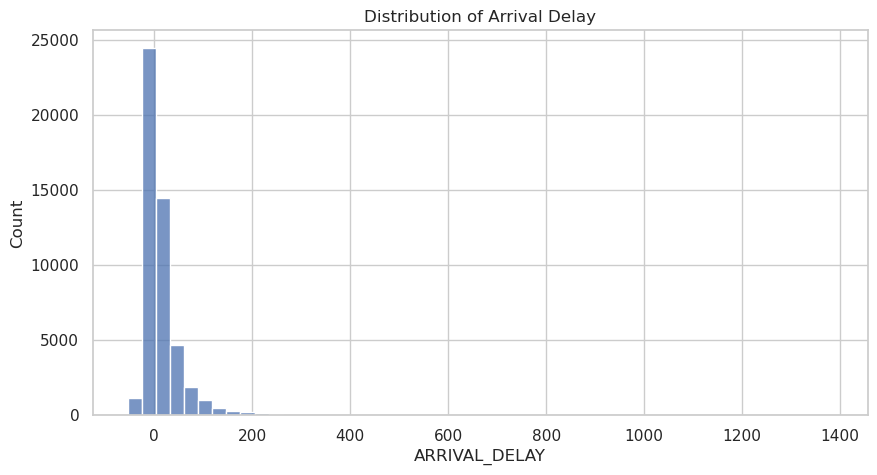

In [17]:
# Distribution of arrival delay
plt.figure(figsize=(10,5))
sns.histplot(df_flights['ARRIVAL_DELAY'].dropna(), bins=50)
plt.title("Distribution of Arrival Delay")
plt.show()

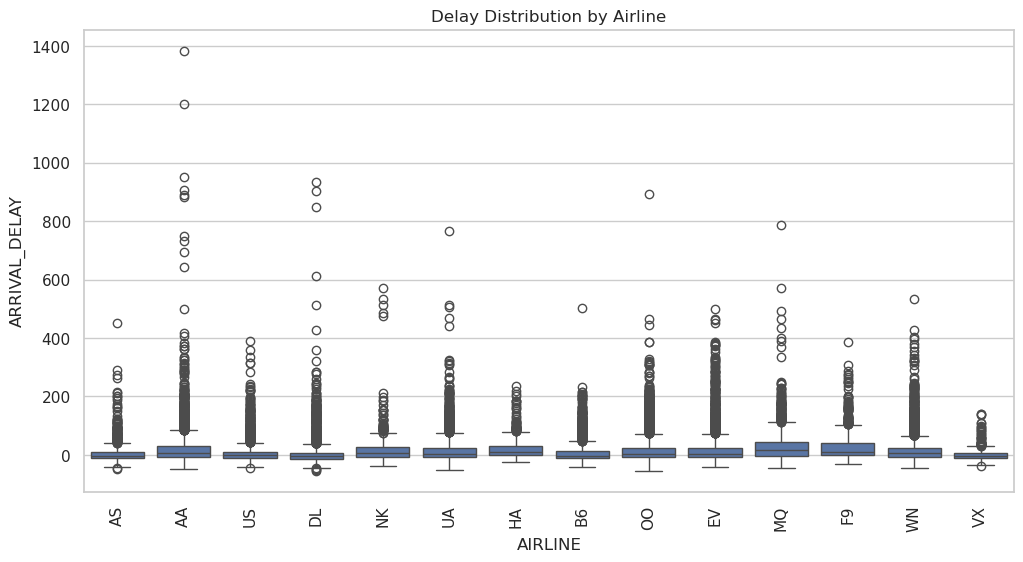

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x='AIRLINE', y='ARRIVAL_DELAY', data=df_flights)
plt.xticks(rotation=90)
plt.title("Delay Distribution by Airline")
plt.show()

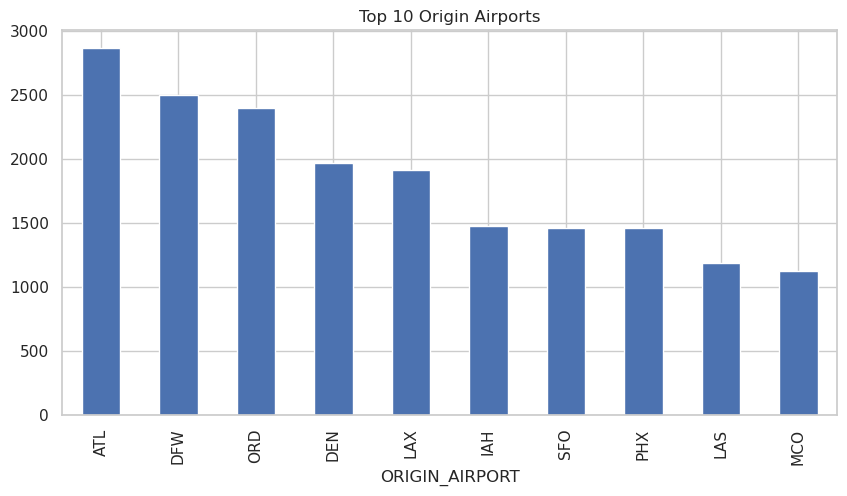

In [19]:
top_airports = df_flights['ORIGIN_AIRPORT'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_airports.plot(kind='bar')
plt.title("Top 10 Origin Airports")
plt.show()

## Data Quality Observations

- Missing values found in ARRIVAL_DELAY and delay-related columns.
- Some delay columns contain many null values, indicating incomplete records.
- Large dataset requires sampling for efficient processing.
- Airport codes must be validated for consistency across datasets.

## Potential Data Bias

- Certain airlines and airports appear more frequently, which may bias the model.
- Seasonal or time-based bias may affect delay predictions.
- Smaller airports may be underrepresented.
- Delays may be influenced by external factors (weather, region).

## Key Features Identified

- Airline (categorical)
- Origin and Destination Airport
- Departure and Arrival Times
- Delay Metrics (arrival_delay, departure_delay)
- Day, Month, Year

These features are critical for predicting flight delays.

## Conclusion

The datasets provide strong coverage of airline operations, airport infrastructure, and flight performance. Initial exploration shows that delays are influenced by airline, airport, and operational factors. Further preprocessing and modeling will be required to build an accurate prediction model.